<center><h1>Patchou_Brice_HW2</h1></center>
<br>
<br>

Name: Brice Patchou
<br>
Github Username: Brice12347
<br>
USC ID: 9034007215

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel("Folds5x2_pp.xlsx")

### (b) Exploring the data

#### i. rows and columns

In [8]:
print(df.head())
rows, cols = df.shape
print(f"There are {rows} rows")
print(f"There are {cols} columns")
print("the rows represent the hourly average ambient variables of the power plant at a particular second")
print("the colums represent the hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)  of the plant.")

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
There are 9568 rows
There are 5 columns
the rows represent the hourly average ambient variables of the power plant at a particular second
the colums represent the hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)  of the plant.


#### ii. pairwise scatterplots of all the varianbles

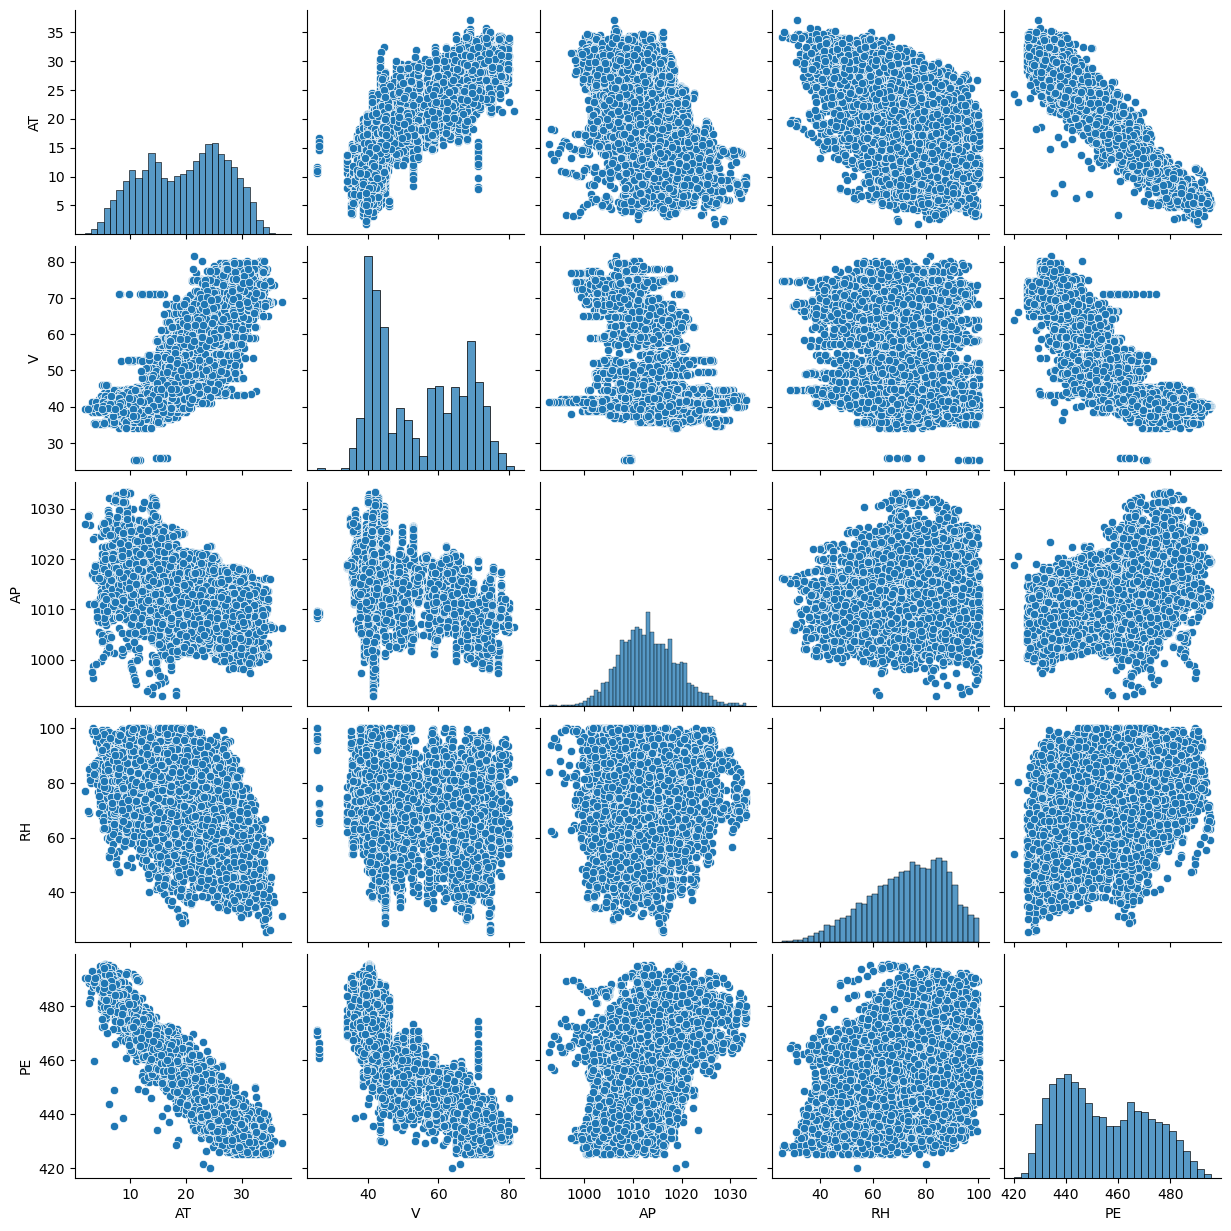

PE and AT are negatively correlated. As AT increases DE decreases.
As AT increases V increases


In [112]:
sns.pairplot(df)
plt.show()
print("PE and AT are negatively correlated. As AT increases DE decreases.")
print("As AT increases V increases")

##### PE and AT are negatively correlated. As AT increases, PE decreases.
##### AT and V are positively correlated. As AT increases, V increases.
##### PE and V are negatively correlated. As PE increases, V decreases.


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [26]:
df.describe(percentiles=None, include=None, exclude=None)
metrics = ['mean', '50%', '25%', '75%']
res = pd.DataFrame()
for m in metrics:
    res[m] = df.describe().loc[m]

ranges = df.describe().loc['max'] - df.describe().loc['min']
iqr = df.describe().loc['75%'] - df.describe().loc['25%']

res['interquarter'] = iqr
res["range"] = ranges
print(res)


           mean       50%        25%      75%  interquarter  range
AT    19.651231    20.345    13.5100    25.72       12.2100  35.30
V     54.305804    52.080    41.7400    66.54       24.8000  56.20
AP  1013.259078  1012.940  1009.1000  1017.26        8.1600  40.41
RH    73.308978    74.975    63.3275    84.83       21.5025  74.60
PE   454.365009   451.550   439.7500   468.43       28.6800  75.50


### (c) Simple Linear Regression

AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:29:03   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


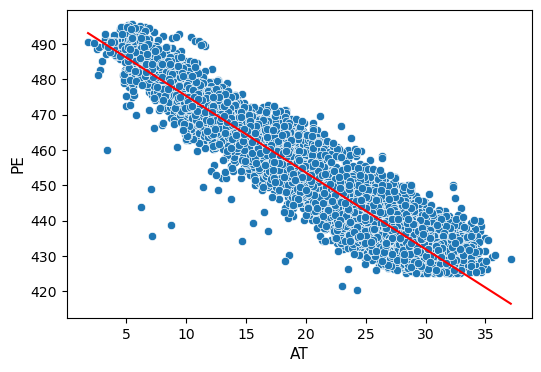

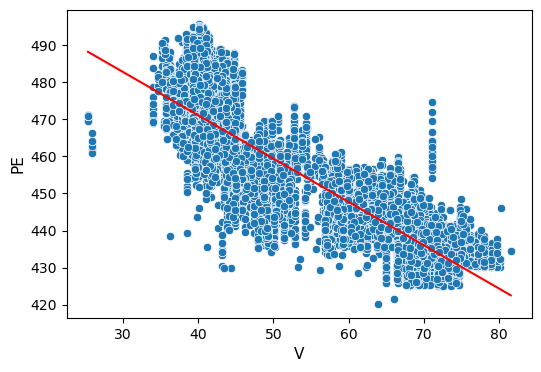

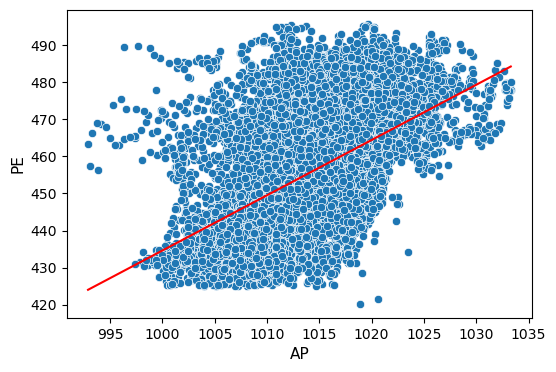

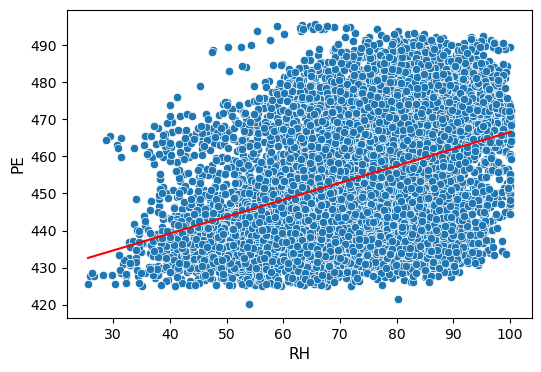

In [ ]:
model = LinearRegression()
independent_var = ["AT", "V","AP", "RH"]
y = df["PE"]



for i in independent_var:
    # print(np.array(df[i]))
    print(i)
    plt.figure(figsize=(6,4))

    sns.scatterplot(x=df[i],y=y)

    # y ~ B1 x + B0
    model.fit(df[[i]], y)
    X_line = np.linspace(df[i].min(), df[i].max(), 100).reshape(-1, 1)
    y_pred = model.predict(X_line)  
    
    results = smf.ols(f'PE ~ {i}', data=df).fit()
    print(results.summary())

    plt.xlabel(i, fontsize=11)
    plt.ylabel("PE", fontsize=11)

    plt.plot(X_line, y_pred, color = "red")

print("they are all statistically significant")

##### All predictors (AT, V, AP, RH) are statistically significant, as all of their p-values are less than 0.05. I did not remove any outliers.

### (d) Multiple Regression

In [117]:
#TODO:
X_line = np.linspace(df.min(), df.max(), 100).reshape(-1, 1)
y_pred = model.predict(X_line)  
results = smf.ols(f'PE ~ AT + V + AP + RH', data=df).fit()
print(results.summary())
print("we can reject the null hypothesis for all predictors as their p values are all less tha 0.05")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:38:54   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##### we can reject the null hypothesis for all predictors as their p values are all less than 0.05

### (e) 1c Compare to 1d

[]

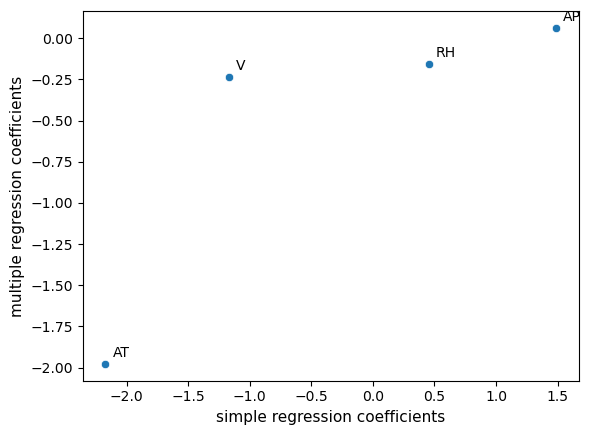

In [ ]:
#TODO:
labels = ['AT', 'V', 'AP', 'RH']
# simple regression coefficients in order of AT, V, AP, RH
simple_coefficient = [-2.1713, -1.1681, 1.4899, 0.4557]

# multiple regression coefficient in order of AT, V, AP, RH
multi_coefficient = [-1.9775, -0.2339, 0.0621, -0.1581]



sns.scatterplot(x=simple_coefficient, y=multi_coefficient)

for i, label in enumerate(labels):
    plt.annotate(label, (simple_coefficient[i], multi_coefficient[i]), textcoords="offset points", xytext=(5,5), ha='left', fontsize=10)


plt.xlabel("simple regression coefficients", fontsize=11)
plt.ylabel("multiple regression coefficients", fontsize=11)
plt.plot()


##### The results from the simple regression differ from multiple regression because the former ignores the correlation between predictors, while multiple regression isolates the true effect of each predictor by holding the other predictors constant. The coefficient of AT remained relatively similar. This means that there is not that much collinearity with AT. The coefficients for V, AP, and RH changed substantially, indicating strong collinearity among the variables.

### (f) Nonlinear Association

In [ ]:
#TODO:
independent_var = ["AT", "V","AP", "RH"]
for i in independent_var:
    results = smf.ols(f'PE ~ {i} +I({i}**2) + I({i}**3)', data=df).fit()
    print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:30:03   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.0

##### There is statistically significant evidence to suggest that there non-linear association with the AT^2, AT^3, V^3, AP^2, AP^3, RH^2, RH^3 predictors has their p values are less than 0.05

### (g) Interactions of Predictors

In [118]:
#TODO:
results = smf.ols(f'PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH ', data=df).fit()
print(results.summary())



                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:42:28   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

##### There is statistically significant evidence to suggest that there exists  association of interactions of predictors with the AT:V, AT:AP, AT:RH, V:AP, AP:RH as their p values are less than 0.05

### (h) Improvement

In [ ]:
#TODO:

X = df[["AT","V","AP","RH"]]
y= df["PE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


training_set = X_train.copy()
training_set['PE'] = y_train
results_full = smf.ols('PE ~ AT + V + AP + RH + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)', data=training_set).fit()
print(results_full.summary())


# ==============================================================================
#                  coef    std err          t      P>|t|      [0.025      0.975]
# ------------------------------------------------------------------------------
# AT            -6.6302      3.781     -1.754      0.080     -14.041       0.781. in
# V             -2.6149      1.792     -1.459      0.145      -6.127       0.898. OUT
# AT:AP          0.0040      0.004      1.100      0.272      -0.003       0.011. 
# V:AP           0.0021      0.002      1.209      0.227      -0.001       0.006
# V:RH        8.279e-05      0.001      0.114      0.909      -0.001       0.002
results_improved = smf.ols('PE ~ AP + RH + AT:V  + AT:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)', data=training_set).fit()


train_pred_full = results_full.predict(X_train)
test_pred_full = results_full.predict(X_test)

train_MSE_full = np.mean((y_train - train_pred_full) ** 2)
test_MSE_full = np.mean((y_test - test_pred_full) ** 2)

print(f"here is the original training mean squared error: {train_MSE_full}")
print(f"here is the original testing mean squared error: {test_MSE_full}")

train_pred_improved = results_improved.predict(X_train)
test_pred_improved = results_improved.predict(X_test)

train_MSE_improved = np.mean((y_train - train_pred_improved) ** 2)
test_MSE_improved = np.mean((y_test - test_pred_improved) ** 2)

print(f"here is the improved training mean squared error: {train_MSE_improved}")
print(f"here is the improved testing mean squared error: {test_MSE_improved}")

print("I removed the predictors that were not necessarily statistically significant, and the errors worsened")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     7620.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:30:02   Log-Likelihood:                -19249.
No. Observations:                6697   AIC:                         3.853e+04
Df Residuals:                    6683   BIC:                         3.862e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7064.6210   1505.364     -4.693      0.0

##### the original training mean squared error: 18.36684744125794
##### the original testing mean squared error: 17.52893740463532
##### the improved training mean squared error: 20.383361851895923
##### the improved testing mean squared error: 19.72253246984402

##### I removed the predictors that were not necessarily statistically significant, and the errors worsened

### (i) KNN

(5.0, 15.6635051689307)


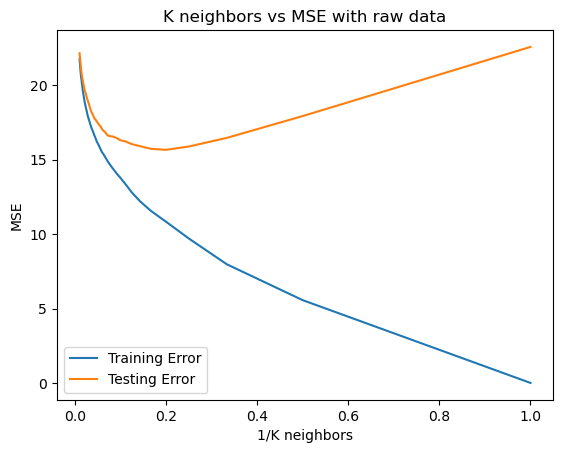

(6.0, 14.419305639730645)


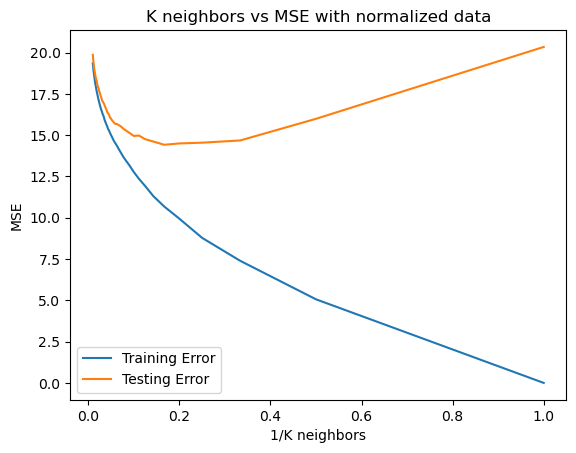

In [119]:
Ks, train_errors, test_errors = [], [], []
for K in range(1,101,1):
    knn = KNeighborsRegressor(n_neighbors=K)
    Ks.append(1/K)

    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    training_error = np.mean((y_train - knn.predict(X_train)) ** 2)
    testing_error = np.mean((y_test - knn_pred) ** 2)

    train_errors.append(training_error)
    test_errors.append(testing_error) 

k_star_index_test = test_errors.index(min(test_errors))
k_star = 1/Ks[k_star_index_test]
print((k_star, min(test_errors)))


plt.plot(Ks,train_errors)
plt.plot(Ks,test_errors)



plt.xlabel("1/K neighbors")
plt.ylabel("MSE")
plt.legend(["Training Error", "Testing Error"])
plt.title("K neighbors vs MSE with raw data")
plt.show()


Ks, train_errors, test_errors = [], [], []

scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train.copy()) 
scaled_X_test = scaler.transform(X_test.copy()) 

Ks, train_errors, test_errors = [], [], []
for K in range(1,101,1):
    knn = KNeighborsRegressor(n_neighbors=K)
    Ks.append(1/K)

    knn_pred = knn.fit(scaled_X_train, y_train).predict(scaled_X_test)
    training_error = np.mean((y_train - knn.predict(scaled_X_train)) ** 2)
    testing_error = np.mean((y_test - knn_pred) ** 2)

    train_errors.append(training_error)
    test_errors.append(testing_error) 

k_star_index_test = test_errors.index(min(test_errors))
k_star = 1/Ks[k_star_index_test]
print((k_star, min(test_errors)))

plt.plot(Ks,train_errors)
plt.plot(Ks,test_errors)

plt.xlabel("1/K neighbors")
plt.ylabel("MSE")
plt.legend(["Training Error", "Testing Error"])
plt.title("K neighbors vs MSE with normalized data")
plt.show()





##### When K=5 and trained on raw data, KNN had the lowest testing MSE (15.664)
##### When K=5 and trained on normalized data, KNN had the lowest testing MSE (13.419)

### (j ) Compare KNN and Linear

##### KNN has a smaller test error than Linear regression. (13.419 < 17.529)

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

In [ ]:
"A flexible model is better suited for this situation, as an inflexible model might underfit."

### (b) The number of predictors p is extremely large, and the number of observations n is small.

In [ ]:
"An inflexible model is better for this situation. A flexible model will overfit with a large number of predictors and low number of observations"

### (c) The relationship between the predictors and response is highly non-linear.

In [ ]:
"A flexible model is better. You need a model that will can adapt to complex patterns."

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

In [ ]:
"An inflexible model is better in this situation because a flexible model will try to overfit to noise."

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [ ]:
"""
OBS 1:SQRT(0^2 + 3^2 + 0^2) = 3
OBS 2:SQRT(2^2 + 0^2 + 0^2) = 2
OBS 3:SQRT(0^2 + 1^2 + 3^2) = 3.1623
OBS 4:SQRT(0^2 + 1^2 + 2^2) = 2.2361
OBS 5:SQRT((-1)^2 + 0^2 + 1^2) = 1.4141
OBS 6:SQRT(1^2 + 1^2 + 1^2) = 1.7321
"""

### (b) What is our prediction with K = 1? Why?

In [ ]:
"green because Observation 5 has the lowest distance. This means that obsearvation 5 is the closest to our new point."

### (c) What is our prediction with K = 3? Why?

In [ ]:
"Green because Observations 4, 5, 6 have the lowest distances and 2 out of the 3 observations are green"

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

In [ ]:
"We would expect the best K-value to be small because the sample size is small"